<a href="https://colab.research.google.com/github/vyenn/ML2024/blob/main/student_hmm_lab_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hidden Markov Model (HMM)

We assume the following HMM model:  
$$
M = (\Sigma, Q, A, B, \pi)
$$

where:

- $Q$ — hidden states (e.g., CpG+ and CpG−)  
- $\Sigma$ — observation symbols (A, C, G, T)  
- $A = [a_{ij}]$ — transition matrix between states  
- $E = [e_j(o)]$ — probability of emitting symbol $(o)$ from state $(j)$  
- $\pi$ — initial state distribution  

---

## For CpG islands – biological interpretation

If we could reconstruct (decode) the **sequence of states $(\Pi)$**,  
we would know which parts of the DNA sequence originate from CpG islands.  

In practice:

- wherever $(\pi_i = CpG+)$  
  → we have a CpG island (a region rich in C and G, often near genes)

In [1]:
import torch

# Hidden states
Q = ["CpG+", "CpG-"]
Q_size = len(Q)

# Observation symbols
observations = ["A", "C", "G", "T"]
M = len(observations)
obs_index = {o: i for i, o in enumerate(observations)}

# Transition matrix between hidden states (CpG+ <-> CpG-)
transition_matrix = torch.tensor([
    [0.8, 0.2],  # CpG+ -> CpG+, CpG-
    [0.2, 0.8]   # CpG- -> CpG+, CpG-
], dtype=torch.float32)


# Emission matrix: probability of emitting each nucleotide from a given state (from lecture)
emission_plus = torch.tensor([
    [0.180, 0.274, 0.426, 0.120],
    [0.171, 0.368, 0.274, 0.188],
    [0.161, 0.339, 0.375, 0.125],
    [0.079, 0.355, 0.384, 0.182]
], dtype=torch.float32)

emission_minus = torch.tensor([
    [0.300, 0.205, 0.285, 0.211],
    [0.322, 0.298, 0.078, 0.302],
    [0.248, 0.246, 0.298, 0.200],
    [0.177, 0.239, 0.292, 0.292]
], dtype=torch.float32)

emission_matrices = torch.stack([emission_plus, emission_minus])  # shape: (2, 4, 4)

# Initial state distribution π for (CpG+, CpG-))
pi = torch.tensor([0.5, 0.5], dtype=torch.float32)

# Example DNA sequence
obs_seq = list("CGCGCGCGCAAAAAAAAAAAAAAAAA")
T = len(obs_seq)

# Convert observation symbols to indices
o = torch.tensor([obs_index[x] for x in obs_seq], dtype=torch.long)

# Forward algorithm:

The Forward algorithm computes the **total probability of observations** up to step (i):  
$$
f_k(i) = P(x_1, x_2, \ldots, x_i, \pi_i = k)
$$

Recursively:  
$$
f_{l}(i) = e_l(x_{i}) \sum_k f_{k}(i-1) a_{kl}
$$

---

### Intuition

> We sum *over all possible paths* ending in state (k).

This answers the question:  
**“How likely is it that the observed sequence was generated by this model?”**


In [8]:
# adapted from SADII_HMM.pdf A.Gambin D.Wojtowicz
# questions m.wierzbinski@uw.edu.pl

def forward(a, e, pi, o):
    """
    Forward algorithm for a CpG model using pairwise emission probabilities.
    a: transition matrix between hidden states (Q_size x Q_size)
    e: emission matrices (Q_size x M x M)
    pi: initial state probabilities (Q_size)
    o: observed sequence (list or tensor of ints)
    """
    Q_size = a.shape[0]
    n = len(o)

    f = torch.zeros((Q_size, n), dtype=torch.float32)
    f[:, 0] = pi * 0.25  # assume uniform emission for first nucleotide

    for i in range(1, n):
        for l in range(Q_size):
            emission = e[l, o[i-1], o[i]]
            f[l, i] = emission * torch.sum(f[:, i-1] * a[:, l])
        # Optional normalization
        # f[:, i] /= torch.sum(f[:, i]) + 1e-12 -- to jest bledne

    P = torch.sum(f[:, -1])
    return f, P

# Backward algorithm –

The Backward algorithm (β) computes the **probability of the remaining observations** from position (i+1) to (L),  
given that at step (t) we are in state (i):  
$$
\beta_k(i) = P(x_{i+1}, x_{i+2}, \ldots, x_L \mid \pi_i = k)
$$

Recursively:  
$$
\beta_k(i) = \sum_j a_{ij} e_i(x_{i+1}) \beta_{i+1}(j)
$$

---

### Intuition

> We calculate the probability of what *is yet to happen*, assuming we are currently in state (i).

In [6]:
import torch

# adapted from SADII_HMM.pdf A.Gambin D.Wojtowicz
# questions m.wierzbinski@uw.edu.pl

def backward(a, e, o):
    """
    Backward algorithm for a CpG model using pairwise emission probabilities.
    a: transition matrix between hidden states (Q_size x Q_size)
    e: emission matrices (Q_size x M x M)
    o: observed sequence (list or tensor of ints)
    """
    Q_size = a.shape[0]

    L = len(o)

    b = torch.zeros((Q_size, L), dtype=torch.float32)
    b[:, -1] = 1.0  # Initialization

    # Recursion: from L-2 down to 0
    for i in range(L - 2, -1, -1):
        for k in range(Q_size):
            # sum over next state j
            b[k, i] = torch.sum(a[k, :] * e[:, o[i], o[i + 1]] * b[:, i + 1])
        # Optional normalization (for numerical stability)
        b[:, i] /= torch.sum(b[:, i]) + 1e-12

    return b

# Forward–Backward combined

The Forward and Backward algorithms can be combined to obtain the **posterior** probability:  
$$
P(\pi_t = k \mid X) = \frac{f_t(k)\beta_t(k)}{P(X)}
$$

In other words:

> “What is the probability that at position (t) in the sequence we were in state (k),  
> given the entire observation X?”


In [7]:
# Compute forward and backward probabilities
f, Px = forward(transition_matrix, emission_matrices, pi, o)
b = backward(transition_matrix, emission_matrices, o)

# Normalize to get posterior probabilities
posterior = (f * b)
posterior /= torch.sum(posterior, dim=0, keepdim=True) + 1e-12
posterior /= Px

print(f"Total probability of the sequence P(x) = {Px:.6f}\n")

# Display posterior probabilities for each position
for t in range(len(o)):
    print(f"Position {t + 1}: {obs_seq[t]}")
    print(f"  P(CpG+ | x) = {posterior[0, t]:.4f}")
    print(f"  P(CpG- | x) = {posterior[1, t]:.4f}")
    print()



Total probability of the sequence P(x) = 1.000000

Position 1: C
  P(CpG+ | x) = 0.7263
  P(CpG- | x) = 0.2737

Position 2: G
  P(CpG+ | x) = 0.8772
  P(CpG- | x) = 0.1228

Position 3: C
  P(CpG+ | x) = 0.8790
  P(CpG- | x) = 0.1210

Position 4: G
  P(CpG+ | x) = 0.9253
  P(CpG- | x) = 0.0747

Position 5: C
  P(CpG+ | x) = 0.8968
  P(CpG- | x) = 0.1032

Position 6: G
  P(CpG+ | x) = 0.9219
  P(CpG- | x) = 0.0781

Position 7: C
  P(CpG+ | x) = 0.8669
  P(CpG- | x) = 0.1331

Position 8: G
  P(CpG+ | x) = 0.8504
  P(CpG- | x) = 0.1496

Position 9: C
  P(CpG+ | x) = 0.6435
  P(CpG- | x) = 0.3565

Position 10: A
  P(CpG+ | x) = 0.3617
  P(CpG- | x) = 0.6383

Position 11: A
  P(CpG+ | x) = 0.2476
  P(CpG- | x) = 0.7524

Position 12: A
  P(CpG+ | x) = 0.1925
  P(CpG- | x) = 0.8075

Position 13: A
  P(CpG+ | x) = 0.1658
  P(CpG- | x) = 0.8342

Position 14: A
  P(CpG+ | x) = 0.1529
  P(CpG- | x) = 0.8471

Position 15: A
  P(CpG+ | x) = 0.1467
  P(CpG- | x) = 0.8533

Position 16: A
  P(CpG+ | x)

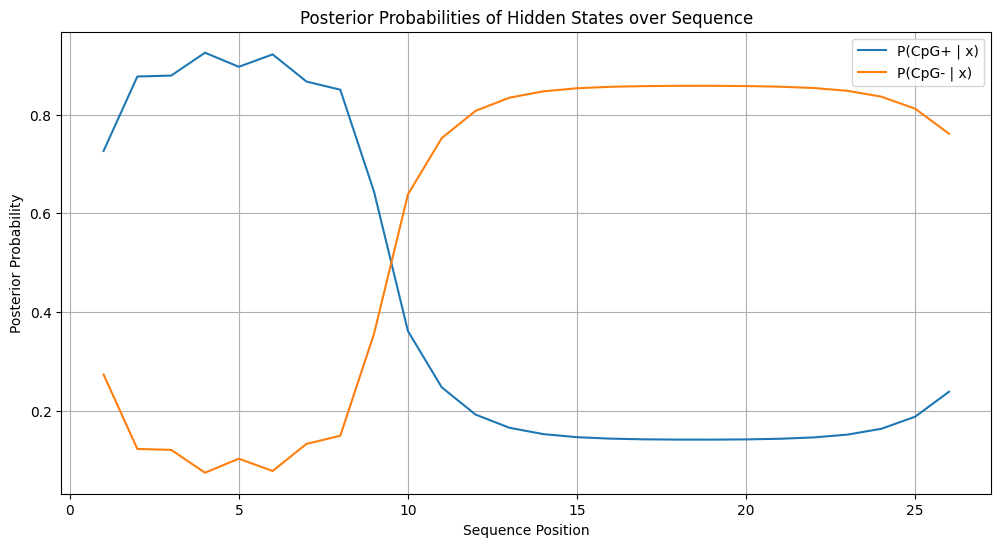

In [5]:
import matplotlib.pyplot as plt

positions = list(range(1, len(obs_seq) + 1))

plt.figure(figsize=(12, 6))
plt.plot(positions, posterior[0, :].numpy(), label="P(CpG+ | x)")
plt.plot(positions, posterior[1, :].numpy(), label="P(CpG- | x)")
plt.xlabel("Sequence Position")
plt.ylabel("Posterior Probability")
plt.title("Posterior Probabilities of Hidden States over Sequence")
plt.legend()
plt.grid(True)
plt.show()

## Viterbi: 4. The Problem We Solve

* **the most probable sequence of hidden states** $(\Pi^*)$

That is:
$$
\Pi^* = \arg\max_\Pi P(X, \Pi)
$$

This is **the sequence of hidden states that most likely generated the observed sequence**.

---

## 5. How Do We Solve It?

That’s exactly what the **Viterbi algorithm** does:

* it searches through all possible state sequences (efficiently, using dynamic programming),
* computes $P(X, \Pi)$ for each possible combination,
* and returns the path $(\Pi^*)$ with the highest probability.

# 6. Viterbi

The Viterbi algorithm looks very similar to the Forward algorithm,  
but instead of taking a **sum over all paths**, it takes the **maximum**:  
$$
v_t(j) = e_j(x_t) \max_i \big[ v_{t-1}(i) a_{ij} \big]
$$

and stores the index:
$$
\phi_t(j) = \arg\max_i \big[ v_{t-1}(i) a_{ij} \big]
$$

→ at the end, we perform a **traceback** using these indices  
to recover the most probable sequence of states $(\Pi^*)$.

---

### Intuition

> Viterbi doesn’t sum over all possible paths —  
> it chooses the single most probable, globally consistent path.

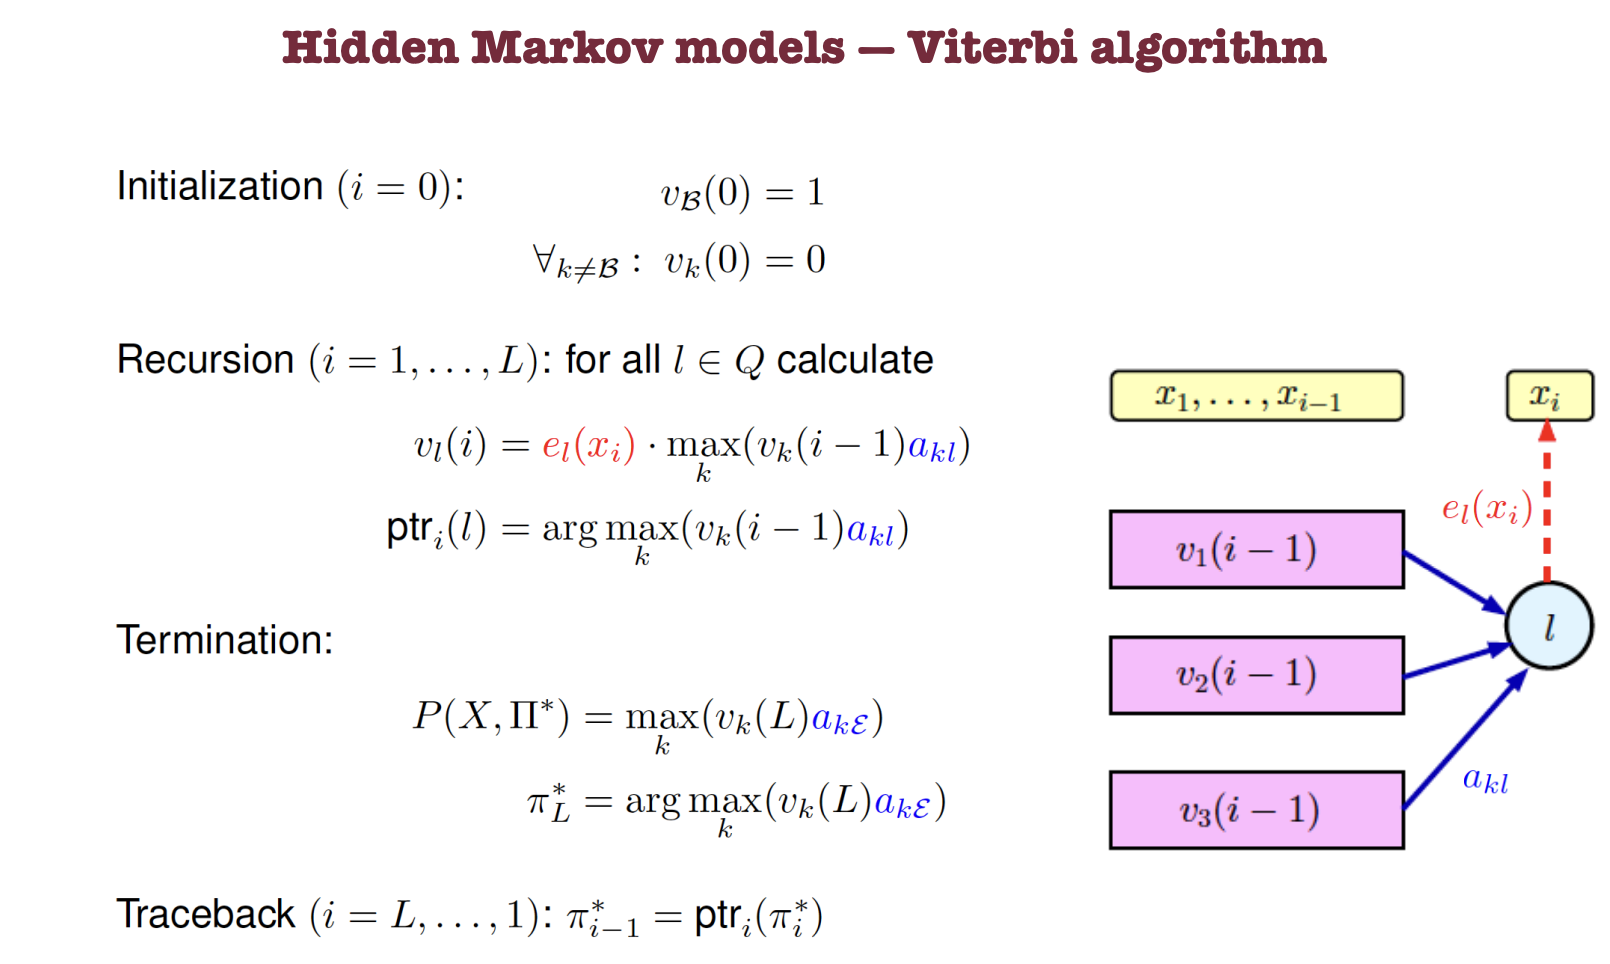

In [ ]:
import torch

# adapted from SADII_HMM.pdf A.Gambin D.Wojtowicz
# questions m.wierzbinski@uw.edu.pl

def viterbi_pairwise(a, e, pi, o):
    """
    Viterbi algorithm (pairwise emission version, log-space)
    --------------------------------------------------------
    Finds the most probable sequence of hidden states (π*)
    for a CpG model where emissions depend on pairs of nucleotides.

    Args:
        a (torch.Tensor): transition matrix [Q_size x Q_size]
        e (torch.Tensor): emission matrices [Q_size x M x M]
        pi (torch.Tensor): initial state distribution [Q_size]
        o (torch.Tensor): sequence of observation indices [T]

    Returns:
        best_path (torch.Tensor): most probable sequence of states
        best_log_prob (float): log probability of the best path
        v (torch.Tensor): DP table of log-probabilities
        ptr (torch.Tensor): backpointers
    """

    Q_size = a.shape[0]
    L = len(o)

    # --- Dynamic programming tables ---
    v = torch.full((Q_size, L), float("-inf"), dtype=torch.float32)
    ptr = torch.zeros((Q_size, L), dtype=torch.long)

    # --- Initialization ---
    # First observation has no previous nucleotide → assume uniform emission (1/4)
    v[:, 0] = torch.log(pi) + torch.log(torch.tensor(1/4))
    ptr[:, 0] = 0
    eps = 1e-12

    # --- Recursion ---
    for i in range(1, L):
        for l in range(Q_size):  # current hidden state
            # compute emission probability for current state and observed transition
            emission = torch.log(e[l, o[i - 1], o[i]] + eps)
            # compute max over previous states
            # problem: extensive multiplication of probabilities might result in
            # underflow. We could use log-sum-exp to avoid this, but it would be
            # more expensive.
            scores = v[:, i - 1] + torch.log(a[:, l] + eps) + emission
            ptr[l, i] = torch.argmax(scores)
            v[l, i] = torch.max(scores)

    # --- Termination ---
    best_last_state = torch.argmax(v[:, -1])
    best_log_prob = v[best_last_state, -1]

    # --- Traceback ---
    best_path = torch.zeros(L, dtype=torch.long)
    best_path[-1] = best_last_state
    for i in range(L - 2, -1, -1):
        best_path[i] = ptr[best_path[i + 1], i + 1]

    return best_path, best_log_prob, v, ptr


# --- Run the algorithm ---
path, logP, v, ptr = viterbi_pairwise(transition_matrix, emission_matrices, pi, o)

print("Most probable sequence of hidden states (Viterbi):\n")
for i, state_idx in enumerate(path):
    print(f"  {obs_seq[i]} → {Q[state_idx]}")
print(f"\nLog P(X, π*) = {logP:.4f}")

Most probable sequence of hidden states (Viterbi):

  C → CpG+
  G → CpG+
  C → CpG+
  G → CpG+
  C → CpG+
  G → CpG+
  C → CpG+
  G → CpG+
  C → CpG+
  A → CpG-
  A → CpG-
  A → CpG-
  A → CpG-
  A → CpG-
  A → CpG-
  A → CpG-
  A → CpG-
  A → CpG-
  A → CpG-
  A → CpG-
  A → CpG-
  A → CpG-
  A → CpG-
  A → CpG-
  A → CpG-
  A → CpG-

Log P(X, π*) = -38.9466


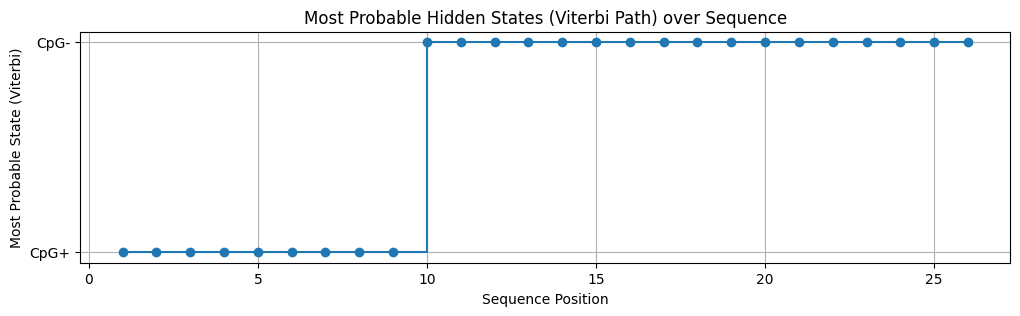

In [ ]:
import matplotlib.pyplot as plt

positions = list(range(1, len(obs_seq) + 1))

viterbi_states = [Q[i] for i in path]

state_mapping = {"CpG+": 0, "CpG-": 1}
viterbi_numeric = [state_mapping[state] for state in viterbi_states]

plt.figure(figsize=(12, 3))
plt.plot(positions, viterbi_numeric, marker='o', linestyle='-', drawstyle='steps-post')
plt.yticks([0, 1], ["CpG+", "CpG-"])
plt.xlabel("Sequence Position")
plt.ylabel("Most Probable State (Viterbi)")
plt.title("Most Probable Hidden States (Viterbi Path) over Sequence")
plt.grid(True)
plt.show()

# Links:
https://web.stanford.edu/~jurafsky/slp3/old_oct19/A.pdf

# Exercise: 'Sometimes a dishonest casino' — HMM modelling in PyTorch

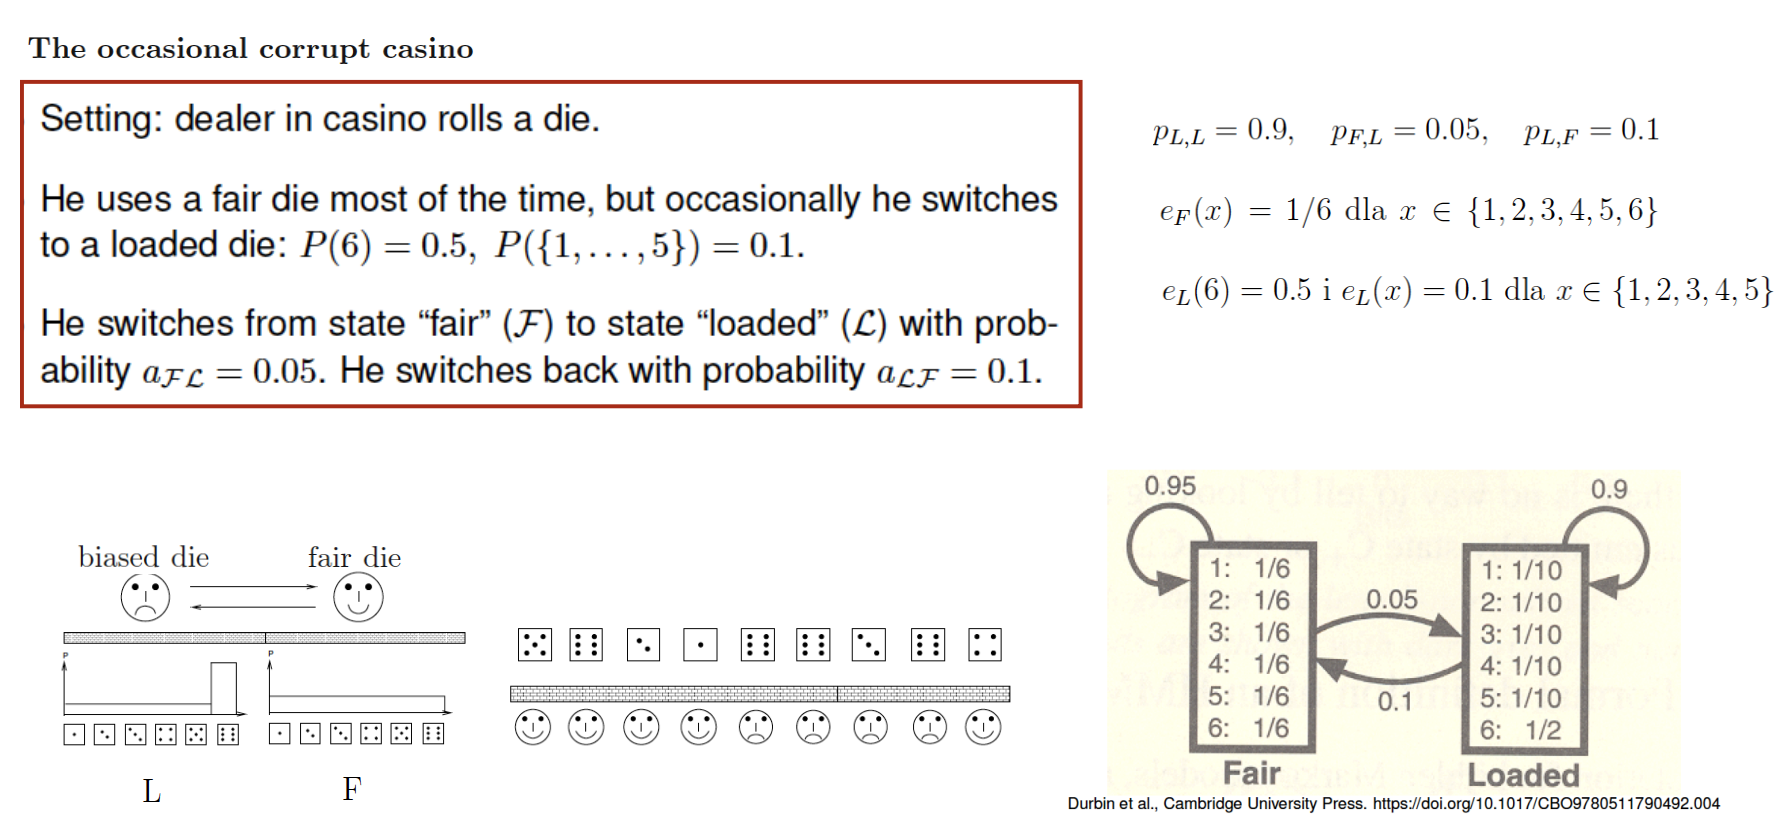

---

## Model description

The casino has two hidden states:
- **Fair** — fair dice (`1–6` each with probability `1/6`)
- **Loaded** — loaded dice (`6` has `0.5`, the rest `1–5` have `0.1`)

### Transitions between states:
| From → To | Fair | Loaded |
|------------|-------|--------|
| Fair       | 0.95  | 0.05   |
| Loaded     | 0.10  | 0.90   |


### Step 1. Define the components of the HMM

In a Hidden Markov Model (HMM), you must specify five key components:

$$
\mathcal{M} = (\Sigma, Q, A, B, \pi)
$$

* `Q` – list of hidden states (in our case: `"Fair"`, `"Loaded"`)
* `Σ` – possible observations (here: dice faces 1–6)
* `A` – transition matrix (probabilities of moving between states)
* `E` – emission matrix (probabilities of rolling each face in a given state)
* `π` – initial state distribution (probability of starting in a given state)

---

### Step 2. Prepare the model HMM in PyTorch

Fill in the template below.
Your task is to:

* define the list of hidden states (`Q`) and observation symbols (`observations`),
* create the transition matrix `A` and emission matrix `E`,
* define the initial distribution `pi`,
* and prepare an example sequence of observed rolls (`obs_seq`).

Remember: in matrices `A` and `E`, **each row must sum to 1** (they represent probability distributions).

* Run algorithms for your model.

---

#### Code template:

```python
# Example observed sequence (example from lecture)
obs_seq = [
    3, 1, 5, 1, 1, 6, 2, 4, 6, 4, 4, 6, 6, 4, 4, 2, 4, 5, 3, 1,
    1, 3, 2, 1, 6, 3, 1, 1, 6, 4, 1, 5, 2, 1, 3, 3, 6, 2, 5, 1,
    4, 4, 5, 4, 3, 6, 3, 1, 6, 5, 6, 2, 6, 5, 6, 6, 6, 6, 6
]
```


## Your solution